In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Resolve outputs path (works from project root or from notebooks/)
base = Path.cwd().resolve() if (Path.cwd().resolve() / "outputs").exists() else Path.cwd().resolve().parent
out = pd.read_pickle(base / "outputs" / "tables" / "rf_display.pkl")

wealth_curves = out["wealth_curves"]
backtest_stats = out["backtest_stats"]
cm_df = out["confusion_matrix"]
roc = out["roc"]

# Random Forest Strategy: Model Description

This document describes the **Random Forest (RF)** strategy for predicting the daily NVDA–TSLA spread direction and trading on it. It focuses on the RF model itself, hyperparameter choice, the rolling backtest setup, hyperparameter learning with Optuna, and (optionally) **profit-based feature selection**. For the prediction target, trading rule, feature definitions, and portfolio metrics, see the logistic model description; only a short recap is given below.

## 1. Objective and Target (recap)

The goal is to predict **which stock will outperform the other tomorrow** using the same setup as the logistic experiment:

- **Target:** $y_t = \mathbf{1}\{s_{t+1} > 0\}$, where $s_{t+1} = r_{\text{NVDA},t+1} - r_{\text{TSLA},t+1}$ is the next-day spread return.
- **Features:** Pair-difference form (NVDA minus TSLA) of accounting and technical variables; no future information. Feature construction is as in the project’s logistic / data pipeline and is not repeated here.
- **Trading:** The model’s class prediction is turned into a directional signal $\hat{d}_t \in \{-1,+1\}$; the strategy return is $\frac{1}{2}\hat{d}_t\, s_{t+1}$, with transaction costs applied (e.g. 5 bps).

## 2. The Random Forest Model

### 2.1 Classifier and prediction

A **Random Forest** is an ensemble of decision trees. Each tree is trained on a bootstrap sample of the training data and at each split considers a random subset of features (`max_features`). Predictions are obtained by **majority vote** across trees: the class (0 or 1) that receives the most votes is the predicted label $\hat{y}_t$.

In this project we use the RF as a **binary classifier**: $\hat{y}_t \in \{0,1\}$ indicates whether the model predicts NVDA (1) or TSLA (0) to outperform the next day. No probability threshold is applied for the core strategy; the voted class is used directly.

### 2.2 From prediction to trading signal

The trading signal is defined as:

$$
\hat{d}_t = \begin{cases} +1, & \hat{y}_t = 1 \quad \text{(long NVDA, short TSLA)} \\ -1, & \hat{y}_t = 0 \quad \text{(long TSLA, short NVDA)} \end{cases}
$$

So we are always in the market (no neutral zone). The daily long–short gross return is $R_{t+1}^{gross} = \frac{1}{2}\hat{d}_t\, s_{t+1}$; net return subtracts transaction costs proportional to signal turnover.

## 3. Hyperparameters and Search Space

The following hyperparameters are tuned (see Section 5):

| Parameter | Role | Search range / options |
|-----------|------|------------------------|
| `n_estimators` | Number of trees in the forest | 50–600 (integer) |
| `max_depth` | Maximum depth of each tree | 3–40 (integer) |
| `min_samples_split` | Minimum samples required to split an internal node | 2–50 (integer) |
| `min_samples_leaf` | Minimum samples in a leaf | 1–20 (integer) |
| `max_features` | Number of features to consider at each split | `"sqrt"`, `"log2"`, or `None` (use all) |
| `random_state` | Reproducibility | Fixed (e.g. 42) |

No manual grid is used; the search is driven by **Optuna** to maximize validation strategy return (Section 5).

## 4. Rolling Backtest Framework

Evaluation is done in a **rolling** manner so that at no point does the test set influence model or hyperparameter choice.

### 4.1 Train / validation / test split (per cycle)

For each cycle we define three consecutive periods:

- **Train:** 5 years of data (used only to fit the model and any scalers).
- **Validation:** 3 months immediately after the training window (used to select hyperparameters and, if applicable, to perform profit-based feature selection).
- **Test:** 3 months immediately after the validation window (used **only once** to report accuracy and strategy performance for that cycle).

So each cycle has the structure: **[Train 5y] [Valid 3mo] [Test 3mo]**.

### 4.2 Step and window

The window is advanced by **3 months** each time: the next cycle’s train (and thus valid and test) start 3 months later. This yields a sequence of non-overlapping test periods that cover the out-of-sample span. All scaling and feature selection use only the current cycle’s training (and, where stated, validation) data.

### 4.3 No test leakage

The test set is never used for:

- fitting scalers (MinMaxScaler is fit on train only);
- choosing the feature set (importance or profit-based selection use train/valid only);
- tuning hyperparameters (Optuna optimizes on validation strategy return).

Final metrics (e.g. cumulative return, accuracy) are reported only on the test window of each cycle; overall performance is then aggregated over all test windows.

## 5. Hyperparameter Learning (Optuna)

### 5.1 Objective: validation strategy return

Hyperparameters are chosen to **maximize** the **validation-set cumulative strategy return** (after transaction costs), not accuracy or log loss. For each trial Optuna:

1. Suggests a set of RF hyperparameters.
2. Trains the RF on the (scaled) training data.
3. Predicts on the validation set and converts predictions to signals $\hat{d}_t \in \{-1,+1\}$.
4. Computes strategy returns, applies turnover-based transaction costs (e.g. 5 bps), and forms the cumulative net return over the validation window.
5. Returns this cumulative return as the objective value; Optuna maximizes it over many trials (e.g. 150).

This aligns the tuning target with the actual trading objective (profit after costs).

### 5.2 Single vs two-phase tuning

- **Single-phase (e.g. `rolling_rf_2.py`):** After an initial feature reduction (e.g. keep only features with RF `feature_importances_` &gt; 0), we run **one** Optuna study on that feature set, then train the final RF with the best params and evaluate on the test window.

- **Two-phase (e.g. `rolling_rf.py`):** After the first Optuna run we apply **profit-based feature selection** (Section 6). Then we run a **second** Optuna study restricted to the chosen feature subset, train the final RF with the new best params, and evaluate on test. So hyperparameters are updated twice: once on the importance-reduced set, once on the profit-selected set.

## 6. Profit-Based Feature Importance and Selection

This step is **optional** and is used in the full pipeline (`rolling_rf.py`) before the second Optuna run.

### 6.1 Permutation profit importance

For each feature $j$, we define a **profit importance** on the validation set:

1. Take the current (scaled) validation feature matrix and the trained RF.
2. **Permute** the $j$-th column (shuffle its values across rows), leaving all other columns unchanged.
3. Predict with the RF on this modified matrix and convert predictions to signals.
4. Compute the validation strategy profit (e.g. $\sum_t \hat{d}_t \cdot s_{t+1}$ or the same with net returns).

This profit is the **profit importance** of feature $j$ under permutation: if the feature is useful, breaking it by permutation should **reduce** profit. So a feature that, when permuted, gives **lower** profit is considered **more important**.

### 6.2 Backward elimination

We then run **backward elimination**:

1. Compute profit importance for all current features (sorted so the least important is last).
2. **Drop** the feature with the **lowest** importance (i.e. the one whose permutation hurt profit the least).
3. Retrain the RF on the reduced feature set (same hyperparameters as after the first Optuna), and repeat from step 1 until only one feature remains.

At each step we record the validation profit (or return). The **selected feature set** is the one that achieved the **highest** validation profit over all steps (not necessarily the last step).

### 6.3 Re-tuning on the selected subset

After fixing the feature set to this best subset, we run a **second** Optuna study: the search space is the same (RF hyperparameters), but the model is now trained and evaluated on the **profit-selected** features only. The best params from this second study are used to train the final RF for the current cycle and to compute test-set accuracy and strategy return.

## 7. Backtest Results

We load the saved outputs from `outputs/rf_outputs/` (produced by `rf_tables.ipynb`) and display:

1. **Cumulative return time series** — RF strategy (gross) vs full-period Long A short B and Long B short A baselines.
2. **Backtest summary table** — hit rate, turnover, annualized return/vol, Sharpe, 5% VaR, max drawdown, Calmar, cumulative return.
3. **Confusion matrix** — actual vs predicted class counts.
4. **ROC curve** — with AUC.

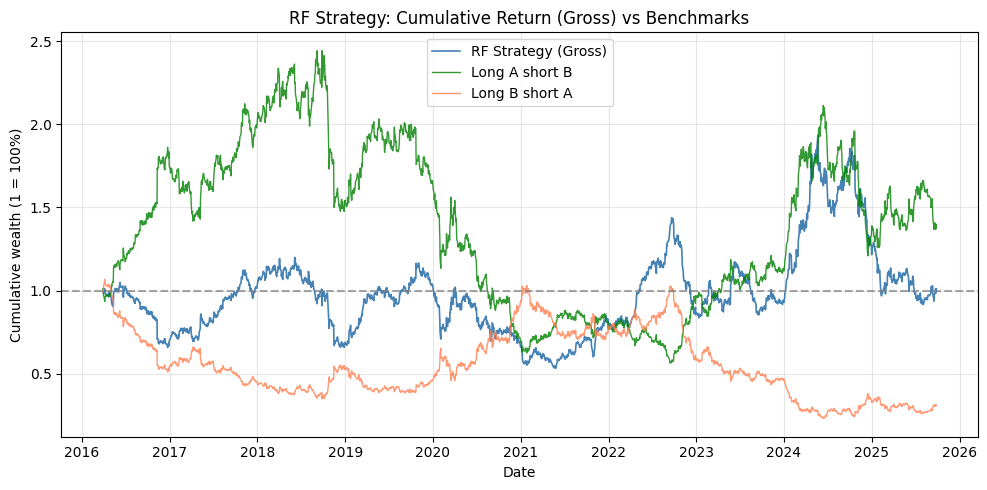

In [9]:
# 1) Cumulative return time series (strategy + baselines)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wealth_curves["date"], wealth_curves["cumulative_wealth"], color="steelblue", linewidth=1.2, label="RF Strategy (Gross)")
ax.plot(wealth_curves["date"], wealth_curves["wealth_long_a_short_b"], color="green", linewidth=1.0, alpha=0.8, label="Long A short B")
ax.plot(wealth_curves["date"], wealth_curves["wealth_long_b_short_a"], color="coral", linewidth=1.0, alpha=0.8, label="Long B short A")
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative wealth (1 = 100%)")
ax.set_title("RF Strategy: Cumulative Return (Gross) vs Benchmarks")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [10]:
# 2) Backtest summary table
display(backtest_stats.T)

,RF Strategy
Accuracy,0.516102
Annualize Turnover,49.008783
Annualize Return,0.001202
Annualize Vol,0.298739
Sharpe,0.004025
5% VaR,-0.029564
Max Drawdown,0.556232
Calmar,0.002162
Cumulative Return,0.011467


,pred_0,pred_1
actual_0,515,654
actual_1,503,719


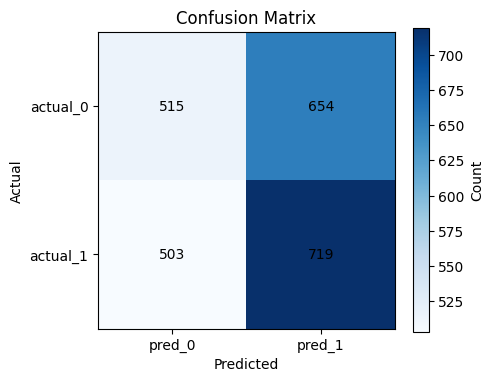

In [11]:
# 3) Confusion matrix (table and heatmap)
display(cm_df)
fig, ax = plt.subplots(figsize=(5, 4))
cm = cm_df.values
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_xticklabels(cm_df.columns)
ax.set_yticks([0, 1])
ax.set_yticklabels(cm_df.index)
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
plt.colorbar(im, ax=ax, label="Count")
ax.set_title("Confusion Matrix")
fig.tight_layout()
plt.show()

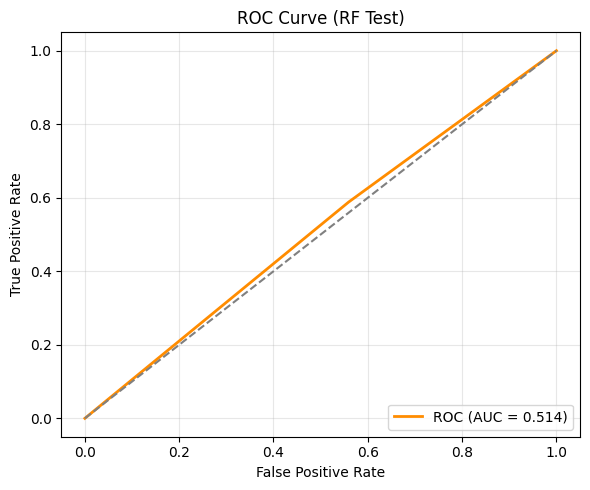

In [12]:
# 4) ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(roc["fpr"], roc["tpr"], color="darkorange", lw=2, label=f"ROC (AUC = {roc['auc']:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve (RF Test)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Key Takeaways

- **Model complexity did not translate into trading success.**  
  Although Random Forest is more flexible than the logistic benchmark, the final rolling backtest remained weak.

- **Feature horizon may be mismatched with the trading target.**  
  Many inputs were quarterly accounting differences, while the prediction target was the **next-day** spread movement. Slow-moving fundamentals may have limited value for short-horizon trading.

- **The pipeline may still suffer from overfitting.**  
  Repeated hyperparameter tuning and profit-based feature selection on the validation set may have adapted the model too closely to historical noise.